# Прогнозирование времени между ДТП

Курсовая работа по задаче регрессии: прогноз времени до следующего ДТП на данных за 2020 год. В работе используются все листы Excel-файла: `ДТП`, `участники`, `ТС`.

## 1. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import ttest_ind, mannwhitneyu

from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, f1_score
from lightgbm import LGBMRegressor
import shap
SHAP_AVAILABLE = True

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
DATA_PATH = '2020.xlsx'


## 2. Загрузка данных

In [2]:
# Загружаем нужные листы Excel-файла
xls = pd.ExcelFile(DATA_PATH)

accidents_raw = pd.read_excel(xls, sheet_name='ДТП')
participants_raw = pd.read_excel(xls, sheet_name='участники')
vehicles_raw = pd.read_excel(xls, sheet_name='ТС')

print('Листы файла:', xls.sheet_names)
print('ДТП:', accidents_raw.shape)
print('Участники:', participants_raw.shape)
print('ТС:', vehicles_raw.shape)


Листы файла: ['ДТП', 'участники', 'ТС']
ДТП: (190436, 46)
Участники: (296156, 11)
ТС: (364043, 13)


## 3. Первичный анализ качества данных

In [3]:
def dataframe_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """тип, пропуски и число уникальных значений"""
    overview = pd.DataFrame({
        'table': name,
        'column': df.columns,
        'dtype': df.dtypes.astype(str).values,
        'missing_count': df.isna().sum().values,
        'missing_percent': (df.isna().mean().values * 100).round(2),
        'unique_count': df.nunique(dropna=True).values
    })
    return overview.sort_values(['missing_percent', 'unique_count'], ascending=[False, False])

overview = pd.concat([
    dataframe_overview(accidents_raw, 'ДТП'),
    dataframe_overview(participants_raw, 'участники'),
    dataframe_overview(vehicles_raw, 'ТС')
], ignore_index=True)

overview.head(30)


,table,column,dtype,missing_count,missing_percent,unique_count
0,ДТП,region_code,float64,190436,100.00,0
1,ДТП,okato_code,float64,190436,100.00,0
2,ДТП,accident_centre,float64,190436,100.00,0
3,ДТП,road_code,float64,190436,100.00,0
4,ДТП,road_sign_code,float64,190436,100.00,0
5,ДТП,road_type_code,float64,190436,100.00,0
6,ДТП,pl_status_code,float64,190436,100.00,0
7,ДТП,state,float64,190436,100.00,0
8,ДТП,wayside_width,float64,189443,99.48,15
9,ДТП,sidewalk_width,float64,189353,99.43,53


### Логика обработки пропусков

- строки без даты/времени удаляются: по ним нельзя посчитать целевую переменную;
- числовые пропуски заполняются медианой внутри `Pipeline`;
- категориальные пропуски заменяются на `Unknown`, а не на моду;
- для важных числовых признаков добавляются флаги пропусков.


In [4]:
accidents_raw['datetime'] = pd.to_datetime(
    accidents_raw['moment_date'].astype(str) + ' ' + accidents_raw['moment_time'].astype(str),
    errors='coerce'
)
accidents_raw['hour'] = accidents_raw['datetime'].dt.hour

hour_counts = (
    accidents_raw.dropna(subset=['hour'])
    .assign(hour=lambda df: df['hour'].astype(int))
    .groupby('hour', as_index=False)
    .size()
    .rename(columns={'size': 'count'})
)

fig = px.bar(
    hour_counts,
    x='hour',
    y='count',
    template='plotly_white',
    title='Распределение ДТП по часам суток',
    labels={'hour': 'Час суток', 'count': 'Количество ДТП'},
    text='count'
)

fig.update_traces(marker_color='#4C78A8', textposition='outside')
fig.update_layout(title_x=0.5, height=520, width=1000, font=dict(size=14), bargap=0.15)
fig.update_xaxes(dtick=1, showgrid=True, gridcolor='#E5E5E5')
fig.update_yaxes(showgrid=True, gridcolor='#E5E5E5')
fig.show()


ДТП распределены по часам неравномерно: временной фактор важен, поэтому в модель добавлены признаки часа, времени суток, выходного дня и часа пик.

## 4. Вспомогательные функции

In [6]:
def get_time_of_day(hour: int) -> str:
    if 6 <= hour < 12:
        return 'morning'
    if 12 <= hour < 18:
        return 'day'
    if 18 <= hour < 24:
        return 'evening'
    return 'night'


def get_season(month: int) -> str:
    if month in [12, 1, 2]:
        return 'winter'
    if month in [3, 4, 5]:
        return 'spring'
    if month in [6, 7, 8]:
        return 'summer'
    return 'autumn'


def make_datetime(date_col: pd.Series, time_col: pd.Series) -> pd.Series:
    """Безопасно объединяет дату и время в один datetime."""
    dates = pd.to_datetime(date_col, errors='coerce')
    times = pd.to_timedelta(time_col.astype(str), errors='coerce')
    return dates + times


## 5. Формирование целевой переменной

In [7]:
accidents = accidents_raw.copy()
accidents = accidents.drop_duplicates(subset=['id']).copy()

accidents['moment_datetime'] = make_datetime(accidents['moment_date'], accidents['moment_time'])
accidents = accidents.dropna(subset=['moment_datetime']).sort_values('moment_datetime').reset_index(drop=True)

# Целевая переменная: сколько секунд пройдет до следующего ДТП.
# Такой вариант логичнее для прогноза: по текущей ситуации оцениваем интервал до следующего события.
accidents['next_moment_datetime'] = accidents['moment_datetime'].shift(-1)
accidents['time_to_next_accident_sec'] = (
    accidents['next_moment_datetime'] - accidents['moment_datetime']
).dt.total_seconds()

# Убираем последнюю строку без следующего ДТП, нулевые/отрицательные интервалы и экстремальные выбросы.
accidents = accidents[accidents['time_to_next_accident_sec'] > 0].copy()
upper_q = accidents['time_to_next_accident_sec'].quantile(0.99)
accidents = accidents[accidents['time_to_next_accident_sec'] <= upper_q].copy()

accidents[['id', 'moment_datetime', 'next_moment_datetime', 'time_to_next_accident_sec']].head()


,id,moment_datetime,next_moment_datetime,time_to_next_accident_sec
1,414364827,2020-01-01 00:05:00,2020-01-01 00:15:00,600.0
2,414405827,2020-01-01 00:15:00,2020-01-01 00:20:00,300.0
3,414451827,2020-01-01 00:20:00,2020-01-01 00:30:00,600.0
4,414365627,2020-01-01 00:30:00,2020-01-01 00:40:00,600.0
6,414386427,2020-01-01 00:40:00,2020-01-01 01:05:00,1500.0


## 6. Использование всех листов: агрегаты участников и транспортных средств

In [8]:
participants = participants_raw.copy()
vehicles = vehicles_raw.copy()

# Агрегаты по участникам ДТП
participants_agg = (
    participants
    .groupby('dtp_id')
    .agg(
        participants_count=('dtp_id', 'size'),
        avg_driver_service_length=('driver_service_length', 'mean'),
        max_driver_service_length=('driver_service_length', 'max'),
        ppos_unique=('ppos_code', 'nunique'),
        pdir_unique=('pdir_code', 'nunique'),
        main_pdd_derangements_count=('main_pdd_derangements', lambda x: x.notna().sum()),
        attendant_pdd_derangements_count=('attendant_pdd_derangements', lambda x: x.notna().sum())
    )
    .reset_index()
)

# Агрегаты по транспортным средствам
vehicles_agg = (
    vehicles
    .groupby('dtp_id')
    .agg(
        vehicles_count=('dtp_id', 'size'),
        transport_type_unique=('transport_type_id', 'nunique'),
        avg_vehicle_year=('year', 'mean'),
        min_vehicle_year=('year', 'min'),
        damaged_parts_count=('damage_dispositions', lambda x: x.notna().sum()),
        owner_org_count=('owner_organization', lambda x: x.notna().sum())
    )
    .reset_index()
)

# Самый частый тип транспорта в ДТП
def safe_mode(x):
    x = x.dropna()
    return x.mode().iloc[0] if len(x.mode()) else np.nan

vehicle_mode = (
    vehicles
    .groupby('dtp_id')['transport_type_name']
    .agg(safe_mode)
    .reset_index()
    .rename(columns={'transport_type_name': 'main_transport_type'})
)

vehicles_agg = vehicles_agg.merge(vehicle_mode, on='dtp_id', how='left')

model_df = (
    accidents
    .merge(participants_agg, left_on='id', right_on='dtp_id', how='left')
    .merge(vehicles_agg, left_on='id', right_on='dtp_id', how='left', suffixes=('', '_veh'))
)

print(model_df.shape)
model_df.head()


(80822, 67)


,id,moment_date,moment_time,type_code,Вид ДТП,transp_amount,loss_amount,loss_child_amount,suffer_amount,suffer_child_amount,place_latitude,place_longitude,region_code,okato_code,place_path,accident_centre,road_code,road_sign_code,road_type_code,road_name,road_loc,pl_status_code,street_name,cut_code,cut_pr_code,traffic_lane_amount,dtp_traffic_lane,traffic_area_width,wayside_width,sidewalk_width,center_mall_width,cmall_type_code,srf_code,tr_area_state_code,light_type_code,rate_code,road_constructions_here,road_constructions_there,meteo_clouds,road_drawbacks,motion_influences,state,suffer_child_amount_16,loss_child_amount_16,area_id,district_id,datetime,hour,moment_datetime,next_moment_datetime,time_to_next_accident_sec,dtp_id,participants_count,avg_driver_service_length,max_driver_service_length,ppos_unique,pdir_unique,main_pdd_derangements_count,attendant_pdd_derangements_count,dtp_id_veh,vehicles_count,transport_type_unique,avg_vehicle_year,min_vehicle_year,damaged_parts_count,owner_org_count,main_transport_type
0,414364827,2020-01-01,00:05:00,1,Столкновение,2,0,0,0,0,55.742266,37.569916,NaN,NaN,Российская Федерация; ЦФО; Москва,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Бережковская наб,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[],[],[],[],NaN,0,0,2,7,2020-01-01 00:05:00,0,2020-01-01 00:05:00,2020-01-01 00:15:00,600.0,414364827.0,2.0,27.0,27.0,0.0,0.0,2.0,2.0,414364827.0,2.0,2.0,NaN,NaN,2.0,1.0,Каршеринг
1,414405827,2020-01-01,00:15:00,1,Столкновение,2,0,0,0,0,55.765094,37.655071,NaN,NaN,Российская Федерация; ЦФО; Москва; Центральный...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Садовая-Черногрязская ул,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[],[],[],[],NaN,0,0,8,116,2020-01-01 00:15:00,0,2020-01-01 00:15:00,2020-01-01 00:20:00,300.0,414405827.0,2.0,30.0,30.0,0.0,0.0,2.0,2.0,414405827.0,2.0,1.0,NaN,NaN,2.0,1.0,Такси
2,414451827,2020-01-01,00:20:00,3,Наезд на стоящее т/с,2,0,0,0,0,55.643360,37.732662,NaN,NaN,Российская Федерация; ЦФО; Москва; Юго-Восточн...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Батайский проезд,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[],[],[],[],NaN,0,0,10,125,2020-01-01 00:20:00,0,2020-01-01 00:20:00,2020-01-01 00:30:00,600.0,414451827.0,2.0,NaN,NaN,0.0,0.0,2.0,2.0,414451827.0,2.0,2.0,NaN,NaN,2.0,0.0,Легковой
3,414365627,2020-01-01,00:30:00,1,Столкновение,2,0,0,0,0,55.850481,37.412288,NaN,NaN,Российская Федерация; ЦФО; Москва; Северо-Запа...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Яна Райниса б-р,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[],[],[],[],NaN,0,0,6,123,2020-01-01 00:30:00,0,2020-01-01 00:30:00,2020-01-01 00:40:00,600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,414365627.0,2.0,2.0,NaN,NaN,2.0,1.0,Автобус
4,414386427,2020-01-01,00:40:00,3,Наезд на стоящее т/с,2,0,0,0,0,55.856208,37.513289,NaN,NaN,Российская Федерация; ЦФО; Москва; Северный АО...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Онежская ул,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[],[],[],[],NaN,0,0,4,143,2020-01-01 00:40:00,0,2020-01-01 00:40:00,2020-01-01 01:05:00,1500.0,414386427.0,2.0,7.0,14.0,0.0,0.0,2.0,2.0,414386427.0,2.0,1.0,NaN,NaN,2.0,0.0,Легковой


## 7. Feature Engineering

Временные признаки

Используем moment_datetime, потому что именно по нему была отсортирована целевая переменная.
Если в данных уже есть datetime, оставляем совместимость.

In [9]:
import pandas as pd
import numpy as np

# Целевая переменная
TARGET = 'time_to_next_accident_sec'

# Создаём пустые списки признаков
numeric_features = []
categorical_features = []

datetime_col = 'moment_datetime' if 'moment_datetime' in model_df.columns else 'datetime'
model_df['datetime'] = pd.to_datetime(model_df[datetime_col])

model_df = model_df.sort_values('datetime').reset_index(drop=True)
model_df['hour'] = model_df['datetime'].dt.hour
model_df['minute'] = model_df['datetime'].dt.minute
model_df['dayofweek'] = model_df['datetime'].dt.dayofweek
model_df['month'] = model_df['datetime'].dt.month
model_df['day'] = model_df['datetime'].dt.day
model_df['weekofyear'] = model_df['datetime'].dt.isocalendar().week.astype(int)
model_df['quarter'] = model_df['datetime'].dt.quarter
model_df['is_weekend'] = model_df['dayofweek'].isin([5, 6]).astype(int)
model_df['is_rush_hour'] = (
    model_df['hour'].between(7, 9) | model_df['hour'].between(17, 19)
).astype(int)
model_df['is_night'] = model_df['hour'].between(0, 5).astype(int)

model_df['time_of_day'] = model_df['hour'].apply(get_time_of_day)
model_df['season'] = model_df['month'].apply(get_season)

# Циклическое кодирование времени: деревьям нужно увидеть, что 23:00 и 00:00 рядом.
model_df['hour_sin'] = np.sin(2 * np.pi * model_df['hour'] / 24)
model_df['hour_cos'] = np.cos(2 * np.pi * model_df['hour'] / 24)
model_df['minute_sin'] = np.sin(2 * np.pi * model_df['minute'] / 60)
model_df['minute_cos'] = np.cos(2 * np.pi * model_df['minute'] / 60)
model_df['dow_sin'] = np.sin(2 * np.pi * model_df['dayofweek'] / 7)
model_df['dow_cos'] = np.cos(2 * np.pi * model_df['dayofweek'] / 7)
model_df['month_sin'] = np.sin(2 * np.pi * model_df['month'] / 12)
model_df['month_cos'] = np.cos(2 * np.pi * model_df['month'] / 12)


Географические признаки

Округленные координаты дают модели устойчивые пространственные зоны без слишком высокой кардинальности.
Если координаты отсутствуют, не подставляем фиктивную точку и не заменяем адрес модой,
а выделяем отдельную категорию Unknown. Это проще защитить на вопросах про адресные пропуски.


In [10]:
model_df['lat_round_2'] = model_df['place_latitude'].round(2)
model_df['lon_round_2'] = model_df['place_longitude'].round(2)

model_df['geo_missing'] = (
    model_df['place_latitude'].isna() | model_df['place_longitude'].isna()
).astype(int)

model_df['geo_cell'] = np.where(
    model_df['geo_missing'].eq(1),
    'Unknown',
    model_df['lat_round_2'].astype(str) + '_' + model_df['lon_round_2'].astype(str)
)

model_df['avg_vehicle_age'] = 2020 - model_df['avg_vehicle_year']
model_df['oldest_vehicle_age'] = 2020 - model_df['min_vehicle_year']

model_df['time_from_prev_global_accident'] = model_df['datetime'].diff().dt.total_seconds()
model_df['time_from_prev_global_accident'] = model_df['time_from_prev_global_accident'].fillna(
    model_df['time_from_prev_global_accident'].median()
)

model_df['time_from_prev_accident_in_cell'] = (
    model_df.groupby('geo_cell')['datetime'].diff().dt.total_seconds()
)
model_df['time_from_prev_accident_in_cell'] = model_df['time_from_prev_accident_in_cell'].fillna(
    model_df['time_from_prev_accident_in_cell'].median()
)

tmp = model_df[['datetime']].copy().set_index('datetime')
tmp['event'] = 1

for hours in [1, 6, 24]:
    model_df[f'accidents_prev_{hours}h'] = (
        tmp['event']
        .rolling(f'{hours}h', closed='left')
        .sum()
        .fillna(0)
        .values
    )


Индикаторы пропусков

не только заполняем пропуски, но и сохраняем информацию о том,
что значение изначально отсутствовало. Это нужно для адресных, погодных
и инфраструктурных признаков, где сам факт пропуска может быть информативным.

In [11]:
# Взаимодействия признаков
model_df['season_time_interaction'] = model_df['season'] + '_' + model_df['time_of_day']
model_df['geo_time_interaction'] = model_df['geo_cell'] + '_' + model_df['time_of_day']

# Признаки по участникам и ТС
model_df['total_participants'] = model_df['participants_count'].fillna(0) + model_df['ppos_unique'].fillna(0)
model_df['accident_with_children'] = (model_df['suffer_child_amount'] > 0).astype(int)
model_df['severity_proxy'] = (
    model_df['loss_amount'].fillna(0)
    + model_df['suffer_amount'].fillna(0)
    + model_df['suffer_child_amount'].fillna(0)
)

# Индикаторы пропусков
missing_indicator_source_cols = [
    'place_latitude', 'place_longitude', 'traffic_lane_amount', 'traffic_area_width',
    'loss_amount', 'loss_child_amount', 'suffer_amount', 'suffer_child_amount',
    'participants_count', 'vehicles_count', 'avg_driver_service_length',
    'avg_vehicle_age', 'oldest_vehicle_age'
]

missing_indicator_features = []
for col in missing_indicator_source_cols:
    if col in model_df.columns:
        flag_col = f'{col}_was_missing'
        model_df[flag_col] = model_df[col].isna().astype(int)
        missing_indicator_features.append(flag_col)

# Обновление списков признаков
numeric_features += [
    'hour', 'minute', 'dayofweek', 'month', 'day', 'weekofyear', 'quarter',
    'is_weekend', 'is_rush_hour', 'is_night',
    'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'transp_amount', 'loss_amount', 'loss_child_amount', 'suffer_amount', 'suffer_child_amount',
    'place_latitude', 'place_longitude', 'lat_round_2', 'lon_round_2',
    'traffic_lane_amount', 'traffic_area_width',
    'participants_count', 'avg_driver_service_length', 'max_driver_service_length',
    'ppos_unique', 'pdir_unique', 'main_pdd_derangements_count', 'attendant_pdd_derangements_count',
    'vehicles_count', 'transport_type_unique', 'avg_vehicle_age', 'oldest_vehicle_age',
    'damaged_parts_count', 'owner_org_count',
    'time_from_prev_global_accident', 'time_from_prev_accident_in_cell',
    'accidents_prev_1h', 'accidents_prev_6h', 'accidents_prev_24h',
    'total_participants', 'severity_proxy', 'geo_missing', 'accident_with_children'
]

numeric_features += missing_indicator_features

categorical_features += [
    'Вид ДТП', 'time_of_day', 'season', 'main_transport_type',
    'road_constructions_here', 'road_constructions_there', 'meteo_clouds',
    'road_drawbacks', 'motion_influences', 'season_time_interaction',
    'geo_cell', 'geo_time_interaction'
]

numeric_features = [col for col in numeric_features if col in model_df.columns]
categorical_features = [col for col in categorical_features if col in model_df.columns]
feature_cols = numeric_features + categorical_features

model_data = model_df[feature_cols + [TARGET, 'datetime']].copy()
model_data = model_data.dropna(subset=[TARGET, 'datetime']).reset_index(drop=True)

print('Количество строк для моделирования:', model_data.shape[0])
print('Количество признаков до OneHot:', len(feature_cols))
display(model_data.head())


Количество строк для моделирования: 80822
Количество признаков до OneHot: 76


,hour,minute,dayofweek,month,day,weekofyear,quarter,is_weekend,is_rush_hour,is_night,hour_sin,hour_cos,minute_sin,minute_cos,dow_sin,dow_cos,month_sin,month_cos,transp_amount,loss_amount,loss_child_amount,suffer_amount,suffer_child_amount,place_latitude,place_longitude,lat_round_2,lon_round_2,traffic_lane_amount,traffic_area_width,participants_count,avg_driver_service_length,max_driver_service_length,ppos_unique,pdir_unique,main_pdd_derangements_count,attendant_pdd_derangements_count,vehicles_count,transport_type_unique,avg_vehicle_age,oldest_vehicle_age,damaged_parts_count,owner_org_count,time_from_prev_global_accident,time_from_prev_accident_in_cell,accidents_prev_1h,accidents_prev_6h,accidents_prev_24h,total_participants,severity_proxy,geo_missing,accident_with_children,place_latitude_was_missing,place_longitude_was_missing,traffic_lane_amount_was_missing,traffic_area_width_was_missing,loss_amount_was_missing,loss_child_amount_was_missing,suffer_amount_was_missing,suffer_child_amount_was_missing,participants_count_was_missing,vehicles_count_was_missing,avg_driver_service_length_was_missing,avg_vehicle_age_was_missing,oldest_vehicle_age_was_missing,Вид ДТП,time_of_day,season,main_transport_type,road_constructions_here,road_constructions_there,meteo_clouds,road_drawbacks,motion_influences,season_time_interaction,geo_cell,geo_time_interaction,time_to_next_accident_sec,datetime
0,0,5,2,1,1,1,1,0,0,1,0.0,1.0,5.000000e-01,8.660254e-01,0.974928,-0.222521,0.5,0.866025,2,0,0,0,0,55.742266,37.569916,55.74,37.57,NaN,NaN,2.0,27.0,27.0,0.0,0.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,1.0,300.0,280620.0,0.0,0.0,0.0,2.0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,Столкновение,night,winter,Каршеринг,[],[],[],[],[],winter_night,55.74_37.57,55.74_37.57_night,600.0,2020-01-01 00:05:00
1,0,15,2,1,1,1,1,0,0,1,0.0,1.0,1.000000e+00,2.832769e-16,0.974928,-0.222521,0.5,0.866025,2,0,0,0,0,55.765094,37.655071,55.77,37.66,NaN,NaN,2.0,30.0,30.0,0.0,0.0,2.0,2.0,2.0,1.0,NaN,NaN,2.0,1.0,600.0,280620.0,1.0,1.0,1.0,2.0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,Столкновение,night,winter,Такси,[],[],[],[],[],winter_night,55.77_37.66,55.77_37.66_night,300.0,2020-01-01 00:15:00
2,0,20,2,1,1,1,1,0,0,1,0.0,1.0,8.660254e-01,-5.000000e-01,0.974928,-0.222521,0.5,0.866025,2,0,0,0,0,55.643360,37.732662,55.64,37.73,NaN,NaN,2.0,NaN,NaN,0.0,0.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,0.0,300.0,280620.0,2.0,2.0,2.0,2.0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,1,Наезд на стоящее т/с,night,winter,Легковой,[],[],[],[],[],winter_night,55.64_37.73,55.64_37.73_night,600.0,2020-01-01 00:20:00
3,0,30,2,1,1,1,1,0,0,1,0.0,1.0,5.665539e-16,-1.000000e+00,0.974928,-0.222521,0.5,0.866025,2,0,0,0,0,55.850481,37.412288,55.85,37.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,NaN,2.0,1.0,600.0,280620.0,3.0,3.0,3.0,0.0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,1,1,Столкновение,night,winter,Автобус,[],[],[],[],[],winter_night,55.85_37.41,55.85_37.41_night,600.0,2020-01-01 00:30:00
4,0,40,2,1,1,1,1,0,0,1,0.0,1.0,-8.660254e-01,-5.000000e-01,0.974928,-0.222521,0.5,0.866025,2,0,0,0,0,55.856208,37.513289,55.86,37.51,NaN,NaN,2.0,7.0,14.0,0.0,0.0,2.0,2.0,2.0,1.0,NaN,NaN,2.0,0.0,600.0,280620.0,4.0,4.0,4.0,2.0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,1,Наезд на стоящее т/с,night,winter,Легковой,[],[],[],[],[],winter_night,55.86_37.51,55.86_37.51_night,1500.0,2020-01-01 00:40:00


## 8. Исследовательский анализ

Графики нужны, чтобы понять форму целевой переменной и проверить, отличается ли время до следующего ДТП в разные периоды суток.

In [12]:
import plotly.express as px

fig = px.histogram(
    model_data,
    x=TARGET,
    nbins=80,
    template="simple_white",
    title="Распределение времени до следующего ДТП"
)

fig.update_traces(
    marker=dict(
        color="#4DB8A8",
        line=dict(color="white", width=0.4)
    )
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Секунды",
    yaxis_title="Количество наблюдений",
    height=600,
    width=1000,
    hovermode="x unified",
    font=dict(size=15)
)

fig.update_xaxes(showgrid=True, gridcolor="#E5E5E5")
fig.update_yaxes(showgrid=True, gridcolor="#E5E5E5")

fig.show()

Распределение скошено вправо: большинство интервалов короткие, но есть редкие длительные паузы. Поэтому целевая переменная логарифмируется перед обучением.

In [13]:
order = ["night", "morning", "day", "evening"]

fig = px.box(
    model_data,
    x="time_of_day",
    y=TARGET,
    color="time_of_day",
    category_orders={"time_of_day": order},
    points="outliers",
    template="plotly_white",
    title="Распределение времени до следующего ДТП по времени суток"
)

fig.update_yaxes(
    type="log",
    title="Время, сек (логарифмическая шкала)"
)

fig.update_xaxes(
    title="Время суток"
)

fig.update_layout(
    title_x=0.5,
    height=650,
    showlegend=False,
    font=dict(size=16)
)

fig.show()

Во все периоды суток есть сильный разброс значений. Логарифмическая шкала нужна, чтобы одновременно видеть типичные интервалы и выбросы.

## 9. Проверка неоднородности выборок

In [14]:
night = model_data.loc[model_data['time_of_day'] == 'night', TARGET].dropna()
day = model_data.loc[model_data['time_of_day'] == 'day', TARGET].dropna()

# Для сильно скошенных распределений дополнительно используем непараметрический тест Манна—Уитни.
t_stat, t_p = ttest_ind(night, day, equal_var=False)
u_stat, u_p = mannwhitneyu(night, day, alternative='two-sided')

print(f'Welch t-test p-value: {t_p:.6f}')
print(f'Mann–Whitney p-value: {u_p:.6f}')

if u_p < 0.05:
    print('Вывод: интервалы между ДТП статистически различаются для дня и ночи.')
else:
    print('Вывод: статистически значимых различий между днем и ночью не обнаружено.')


Welch t-test p-value: 0.000000
Mann–Whitney p-value: 0.000000
Вывод: интервалы между ДТП статистически различаются для дня и ночи.


## 10. Моделирование: Pipeline + RFECV + LightGBM

Данные делятся по времени: train → calibration → test. Это защищает от утечки будущего. `Pipeline` объединяет предобработку, отбор признаков RFECV и модель LightGBM.

In [15]:
model_data = model_data.sort_values('datetime').reset_index(drop=True)

X = model_data[feature_cols]
y = model_data[TARGET]
y_log = np.log1p(y)

n = len(model_data)
train_end = int(n * 0.70)
calib_end = int(n * 0.85)

X_train, y_train_log = X.iloc[:train_end], y_log.iloc[:train_end]
X_calib, y_calib = X.iloc[train_end:calib_end], y.iloc[train_end:calib_end]
X_test, y_test = X.iloc[calib_end:], y.iloc[calib_end:]
y_train_raw = np.expm1(y_train_log)

try:
    ohe = OneHotEncoder(handle_unknown='ignore', min_frequency=5, sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

base_lgbm = LGBMRegressor(
    objective='regression',
    n_estimators=900,
    learning_rate=0.025,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=12,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.90,
    reg_alpha=0.10,
    reg_lambda=0.80,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

selector = RFECV(
    estimator=LGBMRegressor(
        objective='regression',
        n_estimators=250,
        learning_rate=0.04,
        num_leaves=31,
        min_child_samples=15,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=0.50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ),
    step=0.10,
    min_features_to_select=35,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('rfecv', selector),
    ('model', base_lgbm)
])

pipeline.fit(X_train, y_train_log)
print('Модель обучена.')
print('Количество признаков после RFECV:', pipeline.named_steps['rfecv'].n_features_)


Модель обучена.
Количество признаков после RFECV: 35


**Заметка по параметрам.** Меньший `learning_rate` и больше деревьев дают более плавное обучение. `subsample`, `colsample_bytree`, `reg_alpha` и `reg_lambda` снижают риск переобучения

## 11. Оценка качества

Основные метрики регрессии: `MAE`, `RMSE`, `R²`. `Weighted F1` считается дополнительно после разбиения времени на короткие, средние и длинные интервалы.

In [16]:
def predict_seconds(model, X_part: pd.DataFrame) -> np.ndarray:
    pred_log = model.predict(X_part)
    return np.expm1(pred_log).clip(min=0)


def make_bins_from_train(y_train_raw: pd.Series, q: int = 3) -> np.ndarray:
    _, bins = pd.qcut(y_train_raw, q=q, retbins=True, duplicates='drop')
    bins[0] = -np.inf
    bins[-1] = np.inf
    return bins


def apply_bins(values, bins: np.ndarray) -> np.ndarray:
    return pd.cut(values, bins=bins, labels=False, include_lowest=True).astype(int)


y_pred = predict_seconds(pipeline, X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

bins = make_bins_from_train(pd.Series(y_train_raw), q=3)
y_test_bin = apply_bins(y_test, bins)
y_pred_bin = apply_bins(y_pred, bins)
weighted_f1 = f1_score(y_test_bin, y_pred_bin, average='weighted')

metrics = pd.DataFrame({
    'metric': ['R²', 'MAE, sec', 'RMSE, sec', 'Weighted F1 after binning'],
    'value': [r2, mae, rmse, weighted_f1]
})
metrics


,metric,value
0,R²,0.340135
1,"MAE, sec",127.792240
2,"RMSE, sec",218.437543
3,Weighted F1 after binning,0.503781


MAE показывает среднюю ошибку в секундах, RMSE сильнее штрафует крупные ошибки, R² показывает долю объясненной вариации. F1 не является основной метрикой, потому что задача регрессионная.

## 12. Доверительные интервалы прогноза

Интервалы строятся по ошибкам на отдельной калибровочной части. Это показывает неопределенность прогноза.

In [17]:
y_calib_pred = predict_seconds(pipeline, X_calib)
calib_abs_error = np.abs(y_calib.values - y_calib_pred)

alpha = 0.10
q_error = np.quantile(calib_abs_error, 1 - alpha)

lower = np.maximum(0, y_pred - q_error)
upper = y_pred + q_error
coverage = ((y_test.values >= lower) & (y_test.values <= upper)).mean()
avg_width = np.mean(upper - lower)

interval_quality = pd.DataFrame({
    'parameter': ['alpha', 'nominal_coverage', 'actual_test_coverage', 'mean_interval_width_sec'],
    'value': [alpha, 1 - alpha, coverage, avg_width]
})
interval_quality


,parameter,value
0,alpha,0.100000
1,nominal_coverage,0.900000
2,actual_test_coverage,0.911580
3,mean_interval_width_sec,552.704363


Интервалы показывают диапазон, в который прогноз может попасть с учетом типичной ошибки модели на калибровочной выборке.

## 13. Визуализация прогноза

In [18]:
predictions = pd.DataFrame({
    'fact_sec': y_test.values,
    'pred_sec': y_pred,
    'lower_90_sec': lower,
    'upper_90_sec': upper
}).reset_index(drop=True)

sample_plot = predictions.head(300).copy()
sample_plot['obs'] = np.arange(len(sample_plot))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sample_plot['obs'],
    y=sample_plot['upper_90_sec'],
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))

fig.add_trace(go.Scatter(
    x=sample_plot['obs'],
    y=sample_plot['lower_90_sec'],
    mode='lines',
    fill='tonexty',
    fillcolor='rgba(76, 120, 168, 0.18)',
    line=dict(width=0),
    name='90% интервал',
    hovertemplate='Наблюдение: %{x}<br>Нижняя граница: %{y:.0f} сек<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=sample_plot['obs'],
    y=sample_plot['fact_sec'],
    mode='lines',
    name='Факт',
    line=dict(color="#BE88CE", width=2),
    hovertemplate='Наблюдение: %{x}<br>Факт: %{y:.0f} сек<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=sample_plot['obs'],
    y=sample_plot['pred_sec'],
    mode='lines',
    name='Прогноз',
    line=dict(color="#BE5757", width=2),
    hovertemplate='Наблюдение: %{x}<br>Прогноз: %{y:.0f} сек<extra></extra>'
))

fig.update_layout(
    template='plotly_white',
    title='Факт, прогноз и 90% интервал на тестовой выборке',
    title_x=0.5,
    xaxis_title='Наблюдение тестовой выборки',
    yaxis_title='Секунды до следующего ДТП',
    height=620,
    width=1100,
    font=dict(size=14),
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)

fig.update_xaxes(showgrid=True, gridcolor='#E5E5E5')
fig.update_yaxes(showgrid=True, gridcolor='#E5E5E5')
fig.show()


## 14. Интерпретация модели: SHAP

SHAP показывает, какие признаки сильнее всего влияют на прогноз и в какую сторону меняют предсказание.

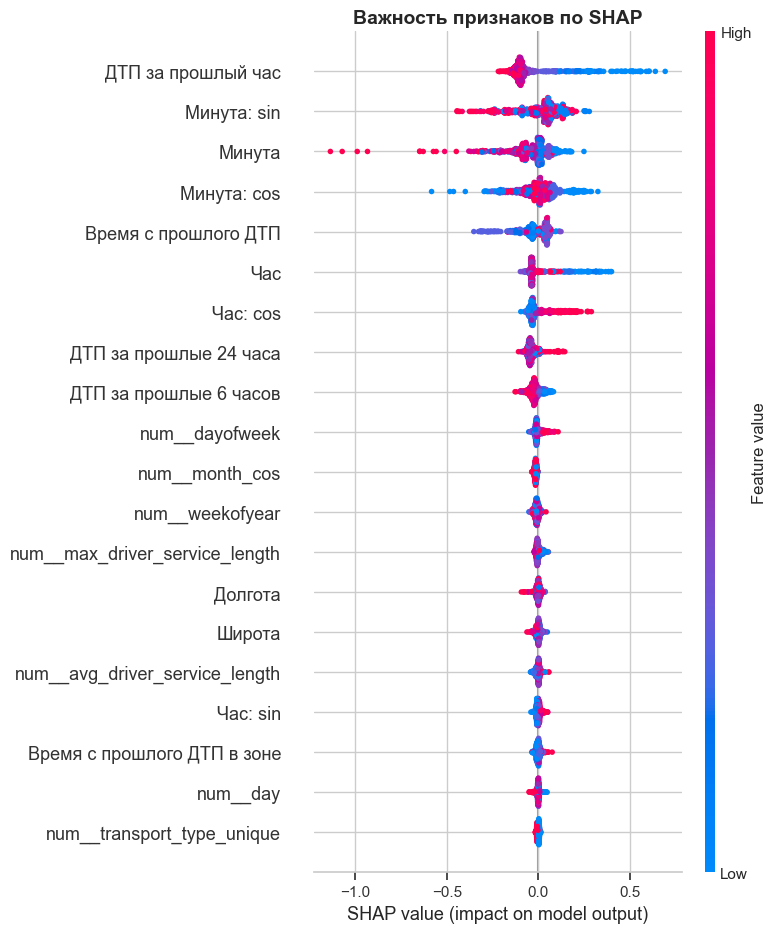

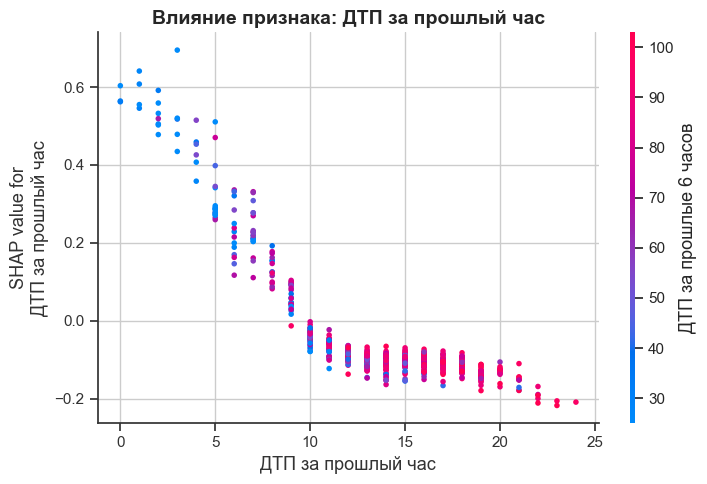

In [19]:
if SHAP_AVAILABLE:
    preprocess = pipeline.named_steps['preprocess']
    rfecv = pipeline.named_steps['rfecv']
    final_model = pipeline.named_steps['model']

    feature_names = preprocess.get_feature_names_out()
    selected_feature_names = feature_names[rfecv.support_]

    shap_sample = X_test.sample(min(700, len(X_test)), random_state=RANDOM_STATE)
    X_transformed = preprocess.transform(shap_sample)
    X_selected = rfecv.transform(X_transformed)

    if hasattr(X_selected, 'toarray'):
        X_selected = X_selected.toarray()

    feature_name_map = {
        'num__accidents_prev_1h': 'ДТП за прошлый час',
        'num__accidents_prev_6h': 'ДТП за прошлые 6 часов',
        'num__accidents_prev_24h': 'ДТП за прошлые 24 часа',
        'num__time_from_prev_global_accident': 'Время с прошлого ДТП',
        'num__time_from_prev_accident_in_cell': 'Время с прошлого ДТП в зоне',
        'num__hour': 'Час',
        'num__minute': 'Минута',
        'num__hour_sin': 'Час: sin',
        'num__hour_cos': 'Час: cos',
        'num__minute_sin': 'Минута: sin',
        'num__minute_cos': 'Минута: cos',
        'num__place_latitude': 'Широта',
        'num__place_longitude': 'Долгота'
    }

    selected_feature_names_pretty = [
        feature_name_map.get(name, name) for name in selected_feature_names
    ]

    X_selected_df = pd.DataFrame(
        X_selected,
        columns=selected_feature_names_pretty,
        index=shap_sample.index
    )

    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_selected_df)

    shap.summary_plot(
        shap_values,
        X_selected_df,
        max_display=20,
        show=False
    )
    plt.title('Важность признаков по SHAP', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    top_feature_idx = int(np.abs(shap_values).mean(axis=0).argmax())
    top_feature = selected_feature_names_pretty[top_feature_idx]

    shap.dependence_plot(
        top_feature,
        shap_values,
        X_selected_df,
        show=False
    )
    plt.title(f'Влияние признака: {top_feature}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('SHAP-блок пропущен, потому что библиотека shap не установлена.')


Summary plot отвечает за общий рейтинг признаков, dependence plot показывает характер влияния самого важного признака.

## 15. Итоговые результаты

In [ ]:
selected_features_report = pd.DataFrame({
    'selected_feature': pipeline.named_steps['preprocess'].get_feature_names_out()[pipeline.named_steps['rfecv'].support_]
})

display(metrics)
display(interval_quality)
display(selected_features_report.head(50))


In [ ]:
sample = X_test.iloc[[0]]
prediction = predict_seconds(pipeline, sample)

print(f"Прогноз времени до следующего ДТП: {prediction[0]:.1f} секунд")

Сначала признаки проходят через Pipeline: обрабатываются пропуски и кодируются категориальные признаки. Затем RFECV оставляет наиболее информативные признаки. После этого LightGBM, используя ансамбль деревьев решений, вычисляет прогноз. Так как модель обучалась на логарифме целевой переменной, полученный результат преобразуется обратно в секунды с помощью функции expm1.